# Computational Carpentry Project

**Group 03**

**Team members:** Pamela Sampaa Afaki, Sarhini Nour, Chiara Nicole Bifulco, Alice Bolard

This notebook builds a molecular-mass calculator from a periodic-table file, uses it to
balance chemical reactions by linear algebra, and ends with two Monte Carlo simulations.
Alongside the working code we have kept the attempts that **did not** work, because
understanding why they failed is what led us to the final versions.

## Part A - Data structures and functions

We first load the periodic-table data and use it to build a molecular mass calculator.
The calculator is developed in three stages: simple formulas, then parentheses, then
hydrates. Each stage reuses the previous one.

### 1. Loading the periodic table

The CSV file is loaded with pandas. We display the first rows to check the column names
and values.

In [1]:
import re
import time
from fractions import Fraction

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Okabe-Ito colourblind-safe palette, used consistently in every figure below.
BLUE, VERMILLION, GREEN, ORANGE = "#0072B2", "#D55E00", "#009E73", "#E69F00"

periodic_table = pd.read_csv("periodic_table.csv")
periodic_table.head()

,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,OxidationStates,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,"+1, -1",Gas,13.81,20.28,0.000090,Nonmetal,1766
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,0,Gas,0.95,4.22,0.000179,Noble gas,1868
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,+1,Solid,453.65,1615.00,0.534000,Alkali metal,1817
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,+2,Solid,1560.00,2744.00,1.850000,Alkaline earth metal,1798
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,+3,Solid,2348.00,4273.00,2.370000,Metalloid,1808


### 2. Creating the atomic mass dictionary

The element symbols are used as keys and their atomic masses as values. This lets us look
up a mass directly from a symbol.

In [2]:
atomic_masses = dict(zip(periodic_table["Symbol"], periodic_table["AtomicMass"]))

print(f"The dictionary holds {len(atomic_masses)} elements.")
{symbol: atomic_masses[symbol] for symbol in ["H", "C", "O", "Ca", "Cu"]}

The dictionary holds 118 elements.


{'H': 1.008, 'C': 12.011, 'O': 15.999, 'Ca': 40.08, 'Cu': 63.55}

All masses used from here on come from this file. Values in the CSV are not always identical
to the rounded numbers in a textbook (it stores Ca as 40.08 rather than 40.078, and S as
32.07 rather than 32.06), so our results are quoted to three decimals against **this** table
rather than against printed reference values.

### 3. Molecular mass of a simple formula

A regular expression separates each element symbol from the number after it. When there is
no number, the count is taken as 1. This first version is meant for formulas without
parentheses or hydration dots.

For a molecule containing $n_i$ atoms of element $i$, the molecular mass is simply
$M = \sum_i n_i A_i$, where $A_i$ is the atomic mass of element $i$.

In [3]:
def molecular_mass_simple(formula):
    tokens = re.findall(r"([A-Z][a-z]?)(\d*)", formula)
    total = 0
    for symbol, number in tokens:
        count = int(number) if number else 1
        total += atomic_masses[symbol] * count
    return total

for formula in ["H2O", "C6H12O6", "NaCl", "CO2"]:
    print(f"{formula}: {molecular_mass_simple(formula):.3f} g/mol")

H2O: 18.015 g/mol
C6H12O6: 180.156 g/mol
NaCl: 58.440 g/mol
CO2: 44.009 g/mol


The values agree with the usual molar masses. This first version works for formulas without
parentheses.

#### What we tried first, and why it failed

Before using a regular expression we wrote a parser that walked through the formula one
character at a time. It looked reasonable and it gave the right answer for `H2O`, which is
exactly what made it dangerous.

In [4]:
def molecular_mass_first_attempt(formula):
    """Our first attempt: assumes every symbol is one letter and every count one digit."""
    total = 0.0
    last_symbol = None
    for character in formula:
        if character.isalpha():
            total += atomic_masses[character]
            last_symbol = character
        elif character.isdigit():
            # "the digit multiplies the element just before it"
            total += atomic_masses[last_symbol] * (int(character) - 1)
    return total

print("H2O     ->", f"{molecular_mass_first_attempt('H2O'):.3f}",
      "  (correct, so we thought the function worked)")
print("C6H12O6 ->", f"{molecular_mass_first_attempt('C6H12O6'):.3f}",
      f"  (WRONG: should be {molecular_mass_simple('C6H12O6'):.3f})")

try:
    molecular_mass_first_attempt("NaCl")
except KeyError as error:
    print("NaCl    -> KeyError", error, " (crashed)")

H2O     -> 18.015   (correct, so we thought the function worked)
C6H12O6 -> 170.076   (WRONG: should be 180.156)
NaCl    -> KeyError 'a'  (crashed)


Two separate faults, and they fail in different ways:

1. **Multi-digit counts.** In `C6H12O6` the `1` and the `2` of "12" are treated as two
   independent counts, so hydrogen is counted twice instead of twelve times. The function
   returns 170.076 instead of 180.156 — a wrong number with **no error message**, which is
   the worse kind of bug.
2. **Two-letter symbols.** In `NaCl` the characters `N`, `a`, `C`, `l` are each looked up on
   their own. `N` and `C` happen to exist in the dictionary, `a` does not, so it crashes.

The lesson is that an element and its subscript form a *single token*, not a sequence of
independent characters: the parser must look ahead for an optional lowercase letter and then
consume **all** following digits. `re.findall(r"([A-Z][a-z]?)(\d*)", formula)` states exactly
that rule in one line, which is why the working version above uses it. The recursive parser
in the next section applies the same look-ahead rule by hand, because it also has to keep
track of its position in the string.

### 4. Parentheses using recursive programming

For a formula such as `Ca(OH)2`, the 2 multiplies everything inside the parentheses. A
recursive parser is useful here because a group inside parentheses is handled in the same way
as the complete formula. It also allows nested groups.

If a group has composition $\{n_i\}$ and is followed by a multiplier $k$, repeating the group
$k$ times gives $kn_i$ atoms of every element. Its mass is therefore

$$\sum_i (kn_i)A_i = k\sum_i n_iA_i.$$

The recursive method applies this same rule at each level of parentheses. The innermost group
is counted first, multiplied by its coefficient, and added to the surrounding group. This
proves the method for nested parentheses by induction on the nesting depth.

#### What we tried first, and why we moved on

Our first idea was to get rid of the parentheses before parsing. The naive version simply
deleted them, which is silently wrong. The second version expanded each group by repeating
the text — that one *does* give the right answer, but we still replaced it, and it is worth
being precise about why.

In [5]:
def mass_deleting_parentheses(formula):
    """Attempt 1: just remove the brackets."""
    return molecular_mass_simple(formula.replace("(", "").replace(")", ""))


def expand_groups(formula):
    """Attempt 2: repeatedly rewrite the innermost group as repeated text."""
    while "(" in formula:
        match = re.search(r"\(([^()]*)\)(\d*)", formula)
        inner, multiplier = match.group(1), int(match.group(2) or 1)
        formula = formula[:match.start()] + inner * multiplier + formula[match.end():]
    return formula

print("Attempt 1, Ca(OH)2      ->", f"{mass_deleting_parentheses('Ca(OH)2'):.3f}",
      " (WRONG: the 2 ended up multiplying only H)")
print("Attempt 2, Ca(OH)2      ->", expand_groups("Ca(OH)2"),
      "->", f"{molecular_mass_simple(expand_groups('Ca(OH)2')):.3f}", " (correct)")
print("Attempt 2, K4(ON(SO3)2)2 ->", expand_groups("K4(ON(SO3)2)2"),
      " (correct, even nested)")

blown_up = expand_groups("(C6H12O6)5000")
print(f"\nBut (C6H12O6)5000 first expands to a string of {len(blown_up):,} characters, "
      "before a single mass has been added up.")

Attempt 1, Ca(OH)2      -> 58.095  (WRONG: the 2 ended up multiplying only H)
Attempt 2, Ca(OH)2      -> CaOHOH -> 74.094  (correct)
Attempt 2, K4(ON(SO3)2)2 -> K4ONSO3SO3ONSO3SO3  (correct, even nested)

But (C6H12O6)5000 first expands to a string of 35,000 characters, before a single mass has been added up.


Attempt 1 is simply wrong: deleting the brackets turns `Ca(OH)2` into `CaOH2`, so the 2
multiplies only the hydrogen and we get 58.095 instead of 74.094.

Attempt 2 is *correct*, and we want to be honest about that rather than claim it failed. We
replaced it for three reasons:

- it rebuilds the whole string on every pass, so the work grows with the size of the
  multiplier rather than with the length of the formula;
- it returns text, but Part B needs the **composition dictionary** (how many atoms of each
  element), so we would have to parse the expanded string all over again;
- the recursive version says what it means: a bracketed group is itself a formula.

Recursion handles nesting for free, runs in a single pass, and hands back the dictionary we
need later. That combination, rather than correctness alone, is why it is the version we
kept.

In [6]:
def add_atoms(total, atoms, multiplier=1):
    for element, number in atoms.items():
        total[element] = total.get(element, 0) + number * multiplier


def parse_section(formula, position=0):
    atoms = {}

    while position < len(formula) and formula[position] != ")":
        if formula[position] == "(":
            group, position = parse_section(formula, position + 1)   # recursive call
            position += 1  # skip the closing parenthesis
            number = ""
            while position < len(formula) and formula[position].isdigit():
                number += formula[position]
                position += 1
            add_atoms(atoms, group, int(number or 1))

        else:
            element = formula[position]
            position += 1
            # look ahead for the lowercase second letter of a two-letter symbol
            if position < len(formula) and formula[position].islower():
                element += formula[position]
                position += 1

            # consume every following digit, not just the first
            number = ""
            while position < len(formula) and formula[position].isdigit():
                number += formula[position]
                position += 1
            atoms[element] = atoms.get(element, 0) + int(number or 1)

    return atoms, position


def parse_formula_with_parentheses(formula):
    atoms, position = parse_section(formula)
    return atoms


def molecular_mass_parentheses(formula):
    composition = parse_formula_with_parentheses(formula)
    return sum(atomic_masses[symbol] * count for symbol, count in composition.items())

for formula in ["Ca(OH)2", "Al2(SO4)3", "K4(ON(SO3)2)2", "Mg3(Si2O5(OH)2)2"]:
    print(f"{formula:18s} {str(parse_formula_with_parentheses(formula)):46s} "
          f"{molecular_mass_parentheses(formula):.3f} g/mol")

Ca(OH)2            {'Ca': 1, 'O': 2, 'H': 2}                      74.094 g/mol
Al2(SO4)3          {'Al': 2, 'S': 3, 'O': 12}                     342.161 g/mol
K4(ON(SO3)2)2      {'K': 4, 'O': 14, 'N': 2, 'S': 4}              536.673 g/mol
Mg3(Si2O5(OH)2)2   {'Mg': 3, 'Si': 4, 'O': 14, 'H': 4}            413.273 g/mol


The nested examples check that recursion works beyond a single pair of parentheses. The parser
first counts the atoms, then the mass calculation uses that composition.

Note that this parser still walks the string character by character — the same overall
strategy as our failed first attempt in section 3. What makes it correct is not abandoning
that strategy but repairing the two specific faults: it looks ahead for a lowercase second
letter, and it consumes digits in a loop instead of one at a time.

### 5. Coordinated water

Hydrates are written as separate parts, for example `CuSO4.5H2O`. We split at the dot, read an
optional coefficient at the beginning of each part, and use the recursive parser for the
remaining formula. The function also accepts the middle-dot symbol `·`.

A hydrate $X\cdot mH_2O$ is one formula unit of $X$ plus $m$ water molecules, so
$M(X\cdot mH_2O)=M(X)+mM(H_2O)$ — which is why the coefficient at the start of each
dot-separated part must multiply that whole part, not just the atom next to it.

In [7]:
def parse_formula(formula):
    """Full parser: handles parentheses, nesting and dot-separated hydrates."""
    total_composition = {}
    parts = formula.replace("·", ".").split(".")

    for part in parts:
        match = re.match(r"(\d*)(.*)", part)
        multiplier = int(match.group(1) or 1)
        part_formula = match.group(2)
        atoms = parse_formula_with_parentheses(part_formula)
        add_atoms(total_composition, atoms, multiplier)

    return dict(total_composition)


def molecular_mass(formula):
    composition = parse_formula(formula)
    return sum(atomic_masses[symbol] * count for symbol, count in composition.items())

for formula in ["CuSO4.5H2O", "CuSO4·5H2O", "MgSO4.7H2O", "Na2CO3.10H2O", "KAl(SO4)2.12H2O"]:
    print(f"{formula:18s} {str(parse_formula(formula)):50s} {molecular_mass(formula):.3f} g/mol")

CuSO4.5H2O         {'Cu': 1, 'S': 1, 'O': 9, 'H': 10}                 249.691 g/mol
CuSO4·5H2O         {'Cu': 1, 'S': 1, 'O': 9, 'H': 10}                 249.691 g/mol
MgSO4.7H2O         {'Mg': 1, 'S': 1, 'O': 11, 'H': 14}                246.476 g/mol
Na2CO3.10H2O       {'Na': 2, 'C': 1, 'O': 13, 'H': 20}                286.138 g/mol
KAl(SO4)2.12H2O    {'K': 1, 'Al': 1, 'S': 2, 'O': 20, 'H': 24}        474.392 g/mol


Both notations for copper(II) sulfate pentahydrate give the same composition and mass, as
expected. The last example combines all three features at once — a two-letter symbol, a
parenthesised group and twelve waters — so `molecular_mass` is now the single function we use
for the rest of the notebook.

## Part B - Stoichiometry and reaction balancing

### 1. Reaction balancer

For each element, the number of atoms on the reactant side must equal the number on the
product side. These conditions form a homogeneous linear system. Reactant columns are positive
and product columns are negative. The singular vector associated with the smallest singular
value gives a solution, which is converted to the smallest set of positive integers.

Let $a_{ij}$ be the number of atoms of element $i$ in species $j$, and let $c_j$ be its
stoichiometric coefficient. Conservation of element $i$ requires

$$\sum_{j\in R} a_{ij}c_j = \sum_{j\in P} a_{ij}c_j.$$

Moving the product terms to the left gives

$$\sum_j A_{ij}c_j=0,$$

where product columns of $A$ have a negative sign. For all elements at once, this is
$A\mathbf{c}=\mathbf{0}$. Therefore a balancing vector lies in the null space of $A$. SVD
identifies this null-space direction, and scaling it to the smallest positive integers gives
the usual stoichiometric coefficients.

#### What we tried first, and why it failed

Our first instinct was to treat this like any other linear system and call `np.linalg.solve`.
Two things went wrong, and both are instructive.

In [8]:
# H2 + O2 -> H2O, written as the matrix A described above
demo_matrix = np.array([[2.0, 0.0, -2.0],    # H
                        [0.0, 2.0, -1.0]])   # O
zero_vector = np.zeros(2)

try:
    np.linalg.solve(demo_matrix, zero_vector)
except np.linalg.LinAlgError as error:
    print("np.linalg.solve ->  LinAlgError:", error)

# Least squares does accept a non-square matrix, so we tried that instead:
least_squares_solution = np.linalg.lstsq(demo_matrix, zero_vector, rcond=None)[0]
print("np.linalg.lstsq  ->  coefficients:", least_squares_solution)

np.linalg.solve ->  LinAlgError: Last 2 dimensions of the array must be square
np.linalg.lstsq  ->  coefficients: [0. 0. 0.]


1. `np.linalg.solve` requires a **square** matrix. Ours has one row per element and one column
   per species, and there is no reason for those to be equal — here it is 2×3.
2. Switching to `lstsq` removes the error but returns `[0, 0, 0]`. That is not a bug: it is the
   honest answer to the question we asked. $A\mathbf{c}=\mathbf{0}$ always has the trivial
   solution $\mathbf{c}=\mathbf{0}$, and it is the *smallest* one, so a least-squares routine
   goes straight to it.

The real question is not "solve $A\mathbf{c}=\mathbf{0}$" but "find a **non-zero direction**
that $A$ sends to zero" — a basis vector for the null space. That is what SVD gives us: the
right-singular vector belonging to the smallest singular value. Recognising that the problem
had been *stated* wrongly, rather than coded wrongly, was the actual step forward.

A second, smaller trap followed. The vector SVD returns has arbitrary sign and scale, so for
water we first got `[0.577, 0.289, 0.577]` rather than `[2, 1, 2]`. Dividing by the smallest
entry, converting to exact fractions and clearing denominators fixes this.

In [9]:
def balance_reaction(reactants, products, max_denominator=1000):
    """Return integer stoichiometric coefficients for reactants + products."""
    formulas = reactants + products
    # parse_formula (not a simplified parser) so parentheses and hydrates also work
    compositions = [parse_formula(f) for f in formulas]
    elements = sorted({element for comp in compositions for element in comp})

    matrix = np.zeros((len(elements), len(formulas)), dtype=float)
    for row, element in enumerate(elements):
        for col, composition in enumerate(compositions):
            sign = 1 if col < len(reactants) else -1
            matrix[row, col] = sign * composition.get(element, 0)

    # A reaction is balanceable only if the null space is non-trivial.
    nullity = len(formulas) - np.linalg.matrix_rank(matrix)
    if nullity == 0:
        raise ValueError("No balancing solution exists for this set of species.")
    if nullity > 1:
        print(f"  warning: {nullity} independent solutions exist; "
              "the reaction as written is ambiguous.")

    U, singular_values, Vh = np.linalg.svd(matrix)
    null_vector = Vh[-1]

    # scale so the smallest non-zero entry is 1, then clear denominators exactly
    non_zero = np.abs(null_vector) > 1e-10
    null_vector = null_vector / np.abs(null_vector[non_zero]).min()
    fractions = [Fraction(float(value)).limit_denominator(max_denominator)
                 for value in null_vector]
    common_denominator = np.lcm.reduce([f.denominator for f in fractions])
    coefficients = [int(f * common_denominator) for f in fractions]

    # the singular vector has an arbitrary sign: fix it, then reduce to lowest terms
    if coefficients[0] < 0:
        coefficients = [-c for c in coefficients]
    common_factor = np.gcd.reduce([abs(c) for c in coefficients])
    coefficients = [c // common_factor for c in coefficients]

    if any(c <= 0 for c in coefficients):
        raise ValueError(f"No all-positive solution found: {coefficients}")
    # verify our own answer: every element must cancel exactly
    assert np.allclose(matrix @ np.array(coefficients, dtype=float), 0), "verification failed"
    return coefficients


def format_reaction(reactants, products, coefficients):
    split = len(reactants)
    left = " + ".join(f"{c if c != 1 else ''}{f}"
                      for c, f in zip(coefficients[:split], reactants))
    right = " + ".join(f"{c if c != 1 else ''}{f}"
                       for c, f in zip(coefficients[split:], products))
    return f"{left} -> {right}"

Two safeguards were added after the first version. The rank check catches species sets that
cannot balance at all, and warns when more than one independent solution exists (a reaction
written ambiguously). The final `assert` recomputes $A\mathbf{c}$ and confirms that every
element cancels exactly — so the function verifies its own answer instead of trusting the
floating-point path that produced it.

We test it on water formation, iron oxidation, ethane combustion, and the oxidation of
hydrochloric acid by permanganate. The last one has six species and is not obvious to balance
by hand, which makes it a far better test than the first three.

In [10]:
test_reactions = [
    (["H2", "O2"], ["H2O"]),
    (["Fe", "O2"], ["Fe2O3"]),
    (["C2H6", "O2"], ["CO2", "H2O"]),
    (["KMnO4", "HCl"], ["KCl", "MnCl2", "H2O", "Cl2"]),
]

balanced_examples = []
for reactants, products in test_reactions:
    coefficients = balance_reaction(reactants, products)
    balanced_examples.append((reactants, products, coefficients))
    print(format_reaction(reactants, products, coefficients))

2H2 + O2 -> 2H2O
4Fe + 3O2 -> 2Fe2O3
2C2H6 + 7O2 -> 4CO2 + 6H2O
2KMnO4 + 16HCl -> 2KCl + 2MnCl2 + 8H2O + 5Cl2


The four outputs match the expected balanced equations:
$2H_2 + O_2 \rightarrow 2H_2O$, $4Fe + 3O_2 \rightarrow 2Fe_2O_3$,
$2C_2H_6 + 7O_2 \rightarrow 4CO_2 + 6H_2O$, and
$2KMnO_4 + 16HCl \rightarrow 2KCl + 2MnCl_2 + 8H_2O + 5Cl_2$.

The permanganate reaction is a redox process that would normally be balanced with
half-equations and oxidation states. The matrix method needs neither: atom conservation alone
fixes the coefficients.

#### Beyond what was asked: parentheses and hydrates in a reaction

The question says we may ignore parentheses and dots in Part B. Because `balance_reaction`
calls the full `parse_formula` from Part A instead of a simplified parser, we get those cases
for free:

In [11]:
for reactants, products in [(["Ca(OH)2", "H3PO4"], ["Ca3(PO4)2", "H2O"]),
                            (["CuSO4.5H2O"], ["CuSO4", "H2O"])]:
    coefficients = balance_reaction(reactants, products)
    print(format_reaction(reactants, products, coefficients))

3Ca(OH)2 + 2H3PO4 -> Ca3(PO4)2 + 6H2O
CuSO4.5H2O -> CuSO4 + 5H2O


### 2. Mass conservation check

The coefficients and molecular masses are used to calculate the total mass represented on each
side. As the question asks, the check is written as a function taking **one dictionary** of
molecules and their coefficients and returning `True` or `False`. Products are stored with
negative coefficients, so a balanced reaction sums to zero. A small numerical tolerance is
included because atomic masses are stored as decimal numbers and floating-point addition is
not exact.

For the reactants, the total mass represented by the equation is

$$M_R=\sum_{j\in R}c_jM_j=\sum_i A_i\left(\sum_{j\in R}c_ja_{ij}\right).$$

The same calculation for the products gives

$$M_P=\sum_i A_i\left(\sum_{j\in P}c_ja_{ij}\right).$$

A balanced equation has the same number of atoms of every element on both sides. The
expressions in parentheses are therefore equal for each $i$, which proves that $M_R=M_P$.

In [12]:
def total_stoichiometric_mass(molecules):
    """Sum of coefficient x molecular mass over a {formula: coefficient} dictionary."""
    return sum(molecular_mass(formula) * coefficient
               for formula, coefficient in molecules.items())


def mass_is_conserved(reaction, tolerance=1e-9):
    """Takes one {formula: coefficient} dictionary, products negative. Returns True/False."""
    return abs(total_stoichiometric_mass(reaction)) <= tolerance


def signed_reaction(reactants, products, coefficients):
    """Build the single dictionary the check expects: products carry a minus sign."""
    reaction = {}
    for index, formula in enumerate(reactants + products):
        sign = 1 if index < len(reactants) else -1
        reaction[formula] = reaction.get(formula, 0) + sign * coefficients[index]
    return reaction


for reactants, products, coefficients in balanced_examples:
    reaction = signed_reaction(reactants, products, coefficients)
    left_mass = total_stoichiometric_mass({f: c for f, c in reaction.items() if c > 0})
    right_mass = -total_stoichiometric_mass({f: c for f, c in reaction.items() if c < 0})
    conserved = mass_is_conserved(reaction)

    print(format_reaction(reactants, products, coefficients))
    print(f"  reactants = {left_mass:.6f} g/mol, products = {right_mass:.6f} g/mol, "
          f"difference = {left_mass - right_mass:+.2e}")
    if conserved:
        print(f"  mass_is_conserved -> {conserved}: mass is conserved, "
              "so the reaction is balanced.\n")
    else:
        print(f"  mass_is_conserved -> {conserved}: mass is NOT conserved, "
              "so the reaction is NOT balanced.\n")

2H2 + O2 -> 2H2O
  reactants = 36.030000 g/mol, products = 36.030000 g/mol, difference = +0.00e+00
  mass_is_conserved -> True: mass is conserved, so the reaction is balanced.

4Fe + 3O2 -> 2Fe2O3
  reactants = 319.354000 g/mol, products = 319.354000 g/mol, difference = +0.00e+00
  mass_is_conserved -> True: mass is conserved, so the reaction is balanced.

2C2H6 + 7O2 -> 4CO2 + 6H2O
  reactants = 284.126000 g/mol, products = 284.126000 g/mol, difference = +5.68e-14
  mass_is_conserved -> True: mass is conserved, so the reaction is balanced.

2KMnO4 + 16HCl -> 2KCl + 2MnCl2 + 8H2O + 5Cl2
  reactants = 899.392680 g/mol, products = 899.392680 g/mol, difference = +1.14e-13
  mass_is_conserved -> True: mass is conserved, so the reaction is balanced.



All four checks return `True`. This matters as more than a formality: the balancing function
and the mass check reach the same conclusion by **different routes** — one through the null
space of an integer matrix, the other through atomic masses read from the CSV. Agreement
between them is real evidence that the coefficients are right.

A note on the tolerance. Comparing with `==` would be wrong here: the two sides are sums of
floating-point numbers added in a different order, so they can differ in the last bit even when
the chemistry is exact. Two of our reactions come out exactly equal and two differ by about
$10^{-13}$ g/mol — far below the $10^{-9}$ tolerance, and roughly $10^{-16}$ of the masses
involved, which is the precision limit of a 64-bit float.

## Part C - Simulation and modeling

### 1. Monte Carlo estimate of $\pi$

Random points are generated in the square $[-1,1] \times [-1,1]$. A point is inside the unit
circle when $x^2+y^2 \leq 1$. Since the circle occupies a fraction $\pi/4$ of the square, four
times the fraction of points inside estimates $\pi$.

The unit circle has area $\pi$ and the surrounding square has area $2\times2=4$. A uniformly
sampled point therefore has probability

$$P(\text{inside})=\frac{\pi}{4}.$$

Define $I_k=1$ when point $k$ is inside the circle and $I_k=0$ otherwise. For $N$ points, the
observed fraction inside is

$$\overline I_N=\frac{1}{N}\sum_{k=1}^{N}I_k.$$

By the law of large numbers, $\overline I_N$ approaches $P(\text{inside})=\pi/4$ as $N$ grows.
Multiplying by 4 gives the estimator

$$\widehat\pi_N=\frac{4}{N}\sum_{k=1}^{N}I_k.$$

It is unbiased because $E[\widehat\pi_N]=4E[I_k]=4(\pi/4)=\pi$.

Because each $I_k$ is an independent Bernoulli variable, the standard error of
$\overline I_N$ is $\sqrt{p(1-p)/N}$, so the error of $\widehat\pi_N$ shrinks like
$N^{-1/2}$. We test that prediction against the simulation below.

In [13]:
def estimate_pi(N, seed=None):
    rng = np.random.default_rng(seed)
    points = rng.uniform(-1, 1, size=(N, 2))
    inside = np.sum(points[:, 0]**2 + points[:, 1]**2 <= 1)
    return 4 * inside / N

pi_estimate = estimate_pi(1_000_000, seed=3)
print(f"Estimated pi:   {pi_estimate:.6f}")
print(f"True pi:        {np.pi:.6f}")
print(f"Absolute error: {abs(pi_estimate - np.pi):.6f}")

Estimated pi:   3.142720
True pi:        3.141593
Absolute error: 0.001127


#### What we tried first, and why we changed it

The first version used a Python `for` loop over `random.random()`. It is correct, and for small
$N$ perfectly usable — but its cost becomes the limiting factor exactly when we need large $N$
to reduce the error.

In [14]:
import random

def estimate_pi_loop(N, seed=None):
    random.seed(seed)
    inside = 0
    for _ in range(N):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        if x * x + y * y <= 1:
            inside += 1
    return 4 * inside / N

N = 1_000_000

start = time.perf_counter()
loop_result = estimate_pi_loop(N, seed=3)
loop_time = time.perf_counter() - start

start = time.perf_counter()
vector_result = estimate_pi(N, seed=3)
vector_time = time.perf_counter() - start

print(f"Python loop: pi = {loop_result:.5f}   in {loop_time:.3f} s")
print(f"NumPy      : pi = {vector_result:.5f}   in {vector_time:.3f} s")
print(f"Speed-up   : {loop_time / vector_time:.0f}x")

Python loop: pi = 3.14264   in 0.157 s
NumPy      : pi = 3.14272   in 0.009 s
Speed-up   : 18x


Both give the same estimate to within their random scatter, so this was never a correctness
problem. But the error only falls as $1/\sqrt{N}$: to gain one more decimal place we need 100
times more points, so the speed of the sampler is what decides the accuracy we can afford.
Vectorised NumPy operations move the work into compiled code and run more than an order of
magnitude faster here, and the gap widens with $N$. That is why the rest of Part C is written
with array operations rather than loops.

To see the convergence clearly, the next calculation uses one sequence of random points and
records the running estimate at increasing values of $N$. We plot the estimate itself on the
left, and the absolute error on log-log axes on the right, where the $N^{-1/2}$ prediction
becomes a straight line.

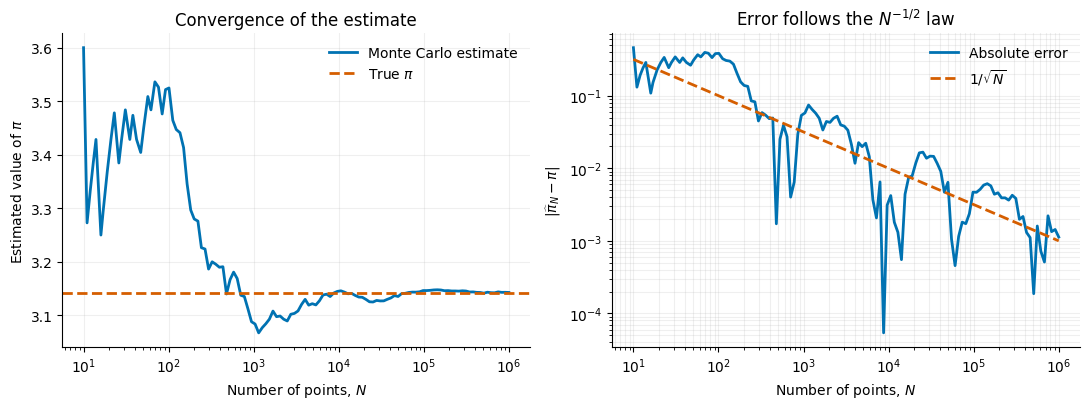

Final estimate at N = 1,000,000: 3.14272  (error 0.00113)


In [15]:
rng = np.random.default_rng(3)
N_max = 1_000_000
points = rng.uniform(-1, 1, size=(N_max, 2))
inside = points[:, 0]**2 + points[:, 1]**2 <= 1
running_estimates = 4 * np.cumsum(inside) / np.arange(1, N_max + 1)

sample_sizes = np.unique(np.logspace(1, 6, 120, dtype=int))
estimates = running_estimates[sample_sizes - 1]
errors = np.abs(estimates - np.pi)

figure, (left_axes, right_axes) = plt.subplots(1, 2, figsize=(11, 4.2))

left_axes.plot(sample_sizes, estimates, color=BLUE, linewidth=2,
               label="Monte Carlo estimate")
left_axes.axhline(np.pi, color=VERMILLION, linestyle="--", linewidth=2,
                  label=r"True $\pi$")
left_axes.set_xscale("log")
left_axes.set_xlabel("Number of points, $N$")
left_axes.set_ylabel(r"Estimated value of $\pi$")
left_axes.set_title("Convergence of the estimate")
left_axes.grid(alpha=0.2)
left_axes.legend(frameon=False)

right_axes.loglog(sample_sizes, errors, color=BLUE, linewidth=2, label="Absolute error")
right_axes.loglog(sample_sizes, 1 / np.sqrt(sample_sizes), color=VERMILLION,
                  linestyle="--", linewidth=2, label=r"$1/\sqrt{N}$")
right_axes.set_xlabel("Number of points, $N$")
right_axes.set_ylabel(r"$|\widehat\pi_N - \pi|$")
right_axes.set_title("Error follows the $N^{-1/2}$ law")
right_axes.grid(alpha=0.2, which="both")
right_axes.legend(frameon=False)

for axes in (left_axes, right_axes):
    axes.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Final estimate at N = {N_max:,}: {estimates[-1]:.5f}  (error {errors[-1]:.5f})")

The estimate fluctuates strongly when only a few points are used. As $N$ increases the
fluctuations shrink and the estimate approaches $\pi$, but not smoothly — the method is random,
so the error jumps around rather than decreasing monotonically.

The right panel is the more informative one. The error tracks the $1/\sqrt{N}$ reference line
over five orders of magnitude, confirming the rate derived above. Its practical meaning is
discouraging: Monte Carlo buys one extra correct digit for every **hundredfold** increase in
sample size, so it is a poor way to compute $\pi$. Its real value is that the same $N^{-1/2}$
rate holds no matter how many dimensions the problem has, which is why the method is used for
integrals that ordinary numerical methods cannot reach.

### 2. Chemistry-inspired Monte Carlo: collision energies and reaction probability

We now simulate $M$ molecular collisions in a box. Each collision is assigned a random energy
and counted as reactive when that energy reaches or exceeds an activation threshold $E_a$. The
fraction of reactive collisions estimates the reaction probability

$$P_{\text{reaction}} \approx \frac{\#\{E_k \geq E_a\}}{M}.$$

This is the same estimator as in the $\pi$ calculation — a fraction of successes, converging
by the same law of large numbers — so we do not repeat that argument here.

The choice of energy distribution is where the chemistry enters. We use an **exponential**
distribution with scale $RT$, i.e. $f(E) = \frac{1}{RT}e^{-E/RT}$. This is a simplified
stand-in for a full molecular collision-energy distribution, but it has the property we care
about: its tail probability is

$$P(E \geq E_a) = e^{-E_a/RT},$$

which is exactly the Boltzmann factor appearing in the Arrhenius equation
$k = A\,e^{-E_a/RT}$. So the simulation can be checked against an analytical answer, and it
should reproduce Arrhenius behaviour. Energies are in kJ/mol throughout, with
$R = 8.314\times10^{-3}$ kJ mol⁻¹ K⁻¹.

Before trusting the exponential case, we validate the machinery on a distribution whose answer
we can work out by hand: energies uniform on $[0, 100]$ with a threshold of 75 must give
exactly 0.25.

In [16]:
GAS_CONSTANT = 8.314e-3   # kJ / (mol K)

def simulate_collisions(M, threshold_energy, distribution="exponential",
                        temperature=None, low=0.0, high=100.0, seed=None):
    """Simulate M collisions; return (estimated probability, energies, reactive count)."""
    rng = np.random.default_rng(seed)

    if distribution == "uniform":
        energies = rng.uniform(low, high, size=M)
    elif distribution == "exponential":
        if temperature is None:
            raise ValueError("The exponential model needs a temperature.")
        energies = rng.exponential(scale=GAS_CONSTANT * temperature, size=M)
    else:
        raise ValueError(f"Unknown distribution: {distribution}")

    reactive = np.count_nonzero(energies >= threshold_energy)
    return reactive / M, energies, reactive


# Sanity check: uniform energies, where the exact answer is (100 - 75) / 100 = 0.25
probability, _, reactive = simulate_collisions(
    200_000, threshold_energy=75.0, distribution="uniform", low=0.0, high=100.0, seed=11
)
print(f"Uniform model: {reactive:,} of 200,000 collisions were reactive")
print(f"  simulated P = {probability:.4f}")
print(f"  exact     P = 0.2500")

Uniform model: 50,107 of 200,000 collisions were reactive
  simulated P = 0.2505
  exact     P = 0.2500


The uniform case reproduces the exact answer to three decimals, so the counting logic is sound.
We can now use the same function with the physically motivated exponential distribution.

In [17]:
ACTIVATION_ENERGY = 50.0     # kJ/mol
M = 2_000_000

temperature = 1200.0
probability, collision_energies, reactive = simulate_collisions(
    M, ACTIVATION_ENERGY, distribution="exponential", temperature=temperature, seed=7
)
analytical = np.exp(-ACTIVATION_ENERGY / (GAS_CONSTANT * temperature))

print(f"Temperature:                    {temperature:.0f} K")
print(f"Activation energy:              {ACTIVATION_ENERGY:.0f} kJ/mol")
print(f"Mean collision energy (RT):     {GAS_CONSTANT * temperature:.2f} kJ/mol")
print(f"Total collisions:               {M:,}")
print(f"Reactive collisions:            {reactive:,}")
print(f"Estimated reaction probability: {probability:.5f}")
print(f"Analytical exp(-Ea/RT):         {analytical:.5f}")
print(f"Relative difference:            {abs(probability - analytical) / analytical:.2%}")

Temperature:                    1200 K
Activation energy:              50 kJ/mol
Mean collision energy (RT):     9.98 kJ/mol
Total collisions:               2,000,000
Reactive collisions:            13,160
Estimated reaction probability: 0.00658
Analytical exp(-Ea/RT):         0.00666
Relative difference:            1.20%


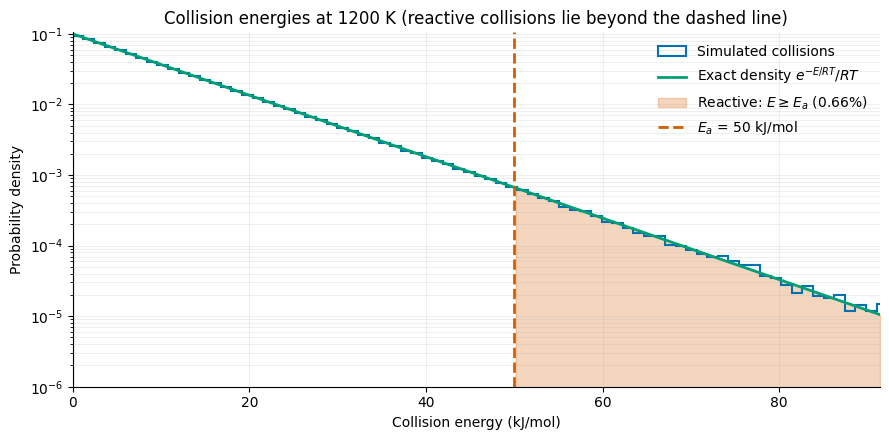

In [18]:
figure, axes = plt.subplots(figsize=(9, 4.5))

upper = np.percentile(collision_energies, 99.99)
RT = GAS_CONSTANT * temperature

# outline rather than a solid fill, so the reactive tail stays visible
axes.hist(collision_energies, bins=120, density=True, histtype="step",
          color=BLUE, linewidth=1.5, label="Simulated collisions")

# overlay the exact density the sampler should be reproducing
energy_grid = np.linspace(0, upper, 400)
exact_density = np.exp(-energy_grid / RT) / RT
axes.plot(energy_grid, exact_density, color=GREEN, linewidth=2,
          label="Exact density $e^{-E/RT}/RT$")

# shade only the reactive collisions
reactive_region = energy_grid >= ACTIVATION_ENERGY
axes.fill_between(energy_grid[reactive_region], 1e-7, exact_density[reactive_region],
                  color=VERMILLION, alpha=0.25,
                  label=f"Reactive: $E \\geq E_a$ ({probability:.2%})")
axes.axvline(ACTIVATION_ENERGY, color=VERMILLION, linestyle="--", linewidth=2,
             label=f"$E_a$ = {ACTIVATION_ENERGY:.0f} kJ/mol")
axes.set_ylim(1e-6, None)

axes.set_yscale("log")
axes.set_xlim(0, upper)
axes.set_xlabel("Collision energy (kJ/mol)")
axes.set_ylabel("Probability density")
axes.set_title(f"Collision energies at {temperature:.0f} K "
               "(reactive collisions lie beyond the dashed line)")
axes.spines[["top", "right"]].set_visible(False)
axes.grid(alpha=0.2, which="both")
axes.legend(frameon=False)

plt.tight_layout()
plt.show()

The logarithmic vertical axis is deliberate. An exponential density becomes a straight line
under a log axis, so this plot doubles as a check that the sampler really produces the
distribution we assumed — the histogram lies on the analytical line over several orders of
magnitude. It also makes the reactive tail visible at all: fewer than 1% of collisions lie
beyond $E_a$, which would be invisible on a linear axis.

#### Temperature dependence

Because the analytical tail probability is known, we can run the simulation across a range of
temperatures and compare every point with theory.

In [19]:
temperatures = np.array([300.0, 500.0, 800.0, 1000.0, 1200.0, 1500.0])

rows = []
for index, T in enumerate(temperatures):
    p_simulated, _, reactive = simulate_collisions(
        M, ACTIVATION_ENERGY, distribution="exponential", temperature=T, seed=100 + index
    )
    rows.append({
        "T (K)": T,
        "RT (kJ/mol)": GAS_CONSTANT * T,
        "reactive collisions": reactive,
        "P simulated": p_simulated,
        "P analytical": np.exp(-ACTIVATION_ENERGY / (GAS_CONSTANT * T)),
    })

results = pd.DataFrame(rows)

# a readable copy (the numeric `results` is reused in the Arrhenius fit below)
display_table = pd.DataFrame({
    "T (K)": results["T (K)"].map("{:.0f}".format),
    "RT (kJ/mol)": results["RT (kJ/mol)"].map("{:.2f}".format),
    "reactive collisions": results["reactive collisions"].map("{:,}".format),
    "P simulated": results["P simulated"].map("{:.3e}".format),
    "P analytical": results["P analytical"].map("{:.3e}".format),
})
display_table

,T (K),RT (kJ/mol),reactive collisions,P simulated,P analytical
0,300,2.49,0,0.000e+00,1.967e-09
1,500,4.16,15,7.500e-06,5.975e-06
2,800,6.65,"1,062",5.310e-04,5.435e-04
3,1000,8.31,"4,946",2.473e-03,2.444e-03
4,1200,9.98,"12,982",6.491e-03,6.660e-03
5,1500,12.47,"36,466",1.823e-02,1.815e-02


At 300 K the simulation reports a probability of exactly **zero**, while theory gives
$2\times10^{-9}$. This is not a programming error, and it is the most useful line in the table.
With $M = 2\times10^6$ collisions the expected number of reactive events at 300 K is
$2\times10^6 \times 2\times10^{-9} \approx 0.004$ — we would need roughly 500 million
collisions before seeing a single one. A Monte Carlo estimate can never resolve a probability
much below $1/M$; it returns zero and gives no warning that it has failed.

This is the **rare-event problem**, a genuine limitation of naive sampling rather than a detail
of our implementation. Real chemistry lives here: an activation energy of 50 kJ/mol at room
temperature is entirely ordinary, and that is exactly the regime where plain Monte Carlo is
useless. Reaching such probabilities requires methods that deliberately bias the sampling
towards the tail (importance sampling and related techniques) and then correct for the bias.

The 500 K row shows the same problem in milder form: 15 reactive collisions out of two million
is enough to give a non-zero answer, but it is off by about 25%, because the relative error of a
count $n$ scales as $1/\sqrt{n}$ and $1/\sqrt{15} \approx 26\%$. From 800 K upward, where
hundreds or thousands of reactive collisions are observed, simulation and theory agree to within
a few percent. The number of *events* observed, not the number of samples drawn, is what
controls the precision.

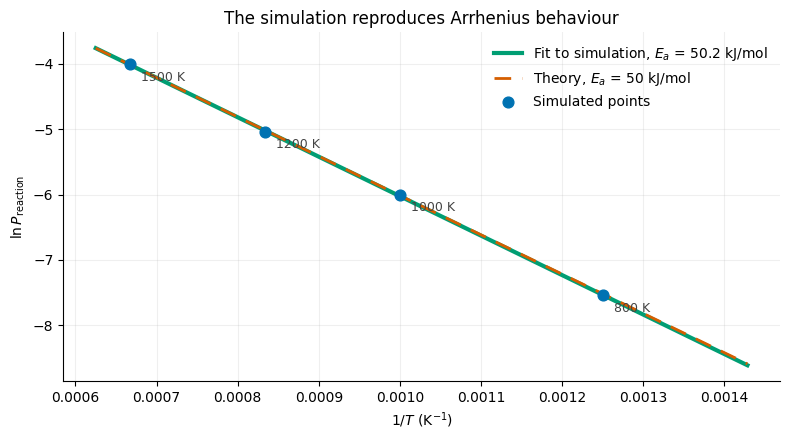

Activation energy used in the simulation: 50.0 kJ/mol
Activation energy recovered from the fit: 50.2 kJ/mol


In [20]:
# Arrhenius check: ln P against 1/T should be a straight line of slope -Ea/R
usable = results[results["reactive collisions"] >= 100]
inverse_T = 1.0 / usable["T (K)"].to_numpy()
log_probability = np.log(usable["P simulated"].to_numpy())

slope, intercept = np.polyfit(inverse_T, log_probability, 1)
recovered_Ea = -slope * GAS_CONSTANT

figure, axes = plt.subplots(figsize=(8, 4.5))

fine_grid = np.linspace(1 / 1600, 1 / 700, 100)
# fit drawn first, theory dashed on top, so the agreement between them is visible
axes.plot(fine_grid, slope * fine_grid + intercept, color=GREEN, linewidth=3,
          label=f"Fit to simulation, $E_a$ = {recovered_Ea:.1f} kJ/mol")
axes.plot(fine_grid, -ACTIVATION_ENERGY / GAS_CONSTANT * fine_grid,
          color=VERMILLION, linestyle=(0, (6, 4)), linewidth=2,
          label=f"Theory, $E_a$ = {ACTIVATION_ENERGY:.0f} kJ/mol")
axes.scatter(inverse_T, log_probability, color=BLUE, s=60, zorder=3,
             label="Simulated points")

for x, y, T in zip(inverse_T, log_probability, usable["T (K)"]):
    axes.annotate(f"{T:.0f} K", (x, y), textcoords="offset points",
                  xytext=(8, -12), fontsize=9, color="#444444")

axes.set_xlabel("$1/T$ (K$^{-1}$)")
axes.set_ylabel(r"$\ln P_{\mathrm{reaction}}$")
axes.set_title("The simulation reproduces Arrhenius behaviour")
axes.spines[["top", "right"]].set_visible(False)
axes.grid(alpha=0.2)
axes.legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"Activation energy used in the simulation: {ACTIVATION_ENERGY:.1f} kJ/mol")
print(f"Activation energy recovered from the fit: {recovered_Ea:.1f} kJ/mol")

This closes the loop. We put an activation energy of 50 kJ/mol into the simulation as a
threshold, counted random collisions, and recovered essentially the same number from the slope
of $\ln P$ against $1/T$ — which is precisely how an experimental chemist extracts an
activation energy from measured rate constants. The Arrhenius exponential is not an extra
assumption here; it emerges from counting how often a randomly drawn energy exceeds a fixed
threshold.

The model stays deliberately simple. It considers energy only, so molecular orientation, the
steric factor and the collision frequency $A$ are all absent, and the exponential distribution
is a stand-in rather than a derived collision-energy distribution. What it does capture is the
part that dominates the temperature dependence of real reaction rates.

## Conclusion

The same lesson turned up in all three parts: **a wrong answer rarely announces itself.** Our
first parser returned a clean number for `C6H12O6` that was off by ten grams per mole. `lstsq`
returned zeros that were mathematically correct and chemically useless. The 300 K simulation
returned a probability of zero and looked no different from a successful run.

None of those raised an error, so the only defence was to check each result against something
independent — a second test case chosen to break the code, a mass balance computed a different
way, an analytical formula. That habit, rather than any particular piece of Python, is what we
would carry into the next project. Fixing the random seed matters for the same reason: a number
you cannot reproduce is a number you cannot check.